<h2> Preprocessing & Cropping</h2>

In [1]:
from change_detection import (

    crop_tiff_to_shapefile,
    save_cropped_polarizations_plot
)

In [2]:
# Define directory paths
shishper_base_dir = "shishper_bursts"
shishper_shape = "shishper_shapefile/shishper glacier.shp"

In [3]:
time_series=crop_tiff_to_shapefile(shishper_base_dir, shishper_shape)


Processing burst folder: 2025_04_05
   Cropped TIFF saved at: shishper_bursts\2025_04_05\VV_shape.tif
   VV processed: shishper_bursts\2025_04_05\VV_shape.tif
   Cropped TIFF saved at: shishper_bursts\2025_04_05\VH_shape.tif
   VH processed: shishper_bursts\2025_04_05\VH_shape.tif

Processing burst folder: 2025_04_17
   Cropped TIFF saved at: shishper_bursts\2025_04_17\VV_shape.tif
   VV processed: shishper_bursts\2025_04_17\VV_shape.tif
   Cropped TIFF saved at: shishper_bursts\2025_04_17\VH_shape.tif
   VH processed: shishper_bursts\2025_04_17\VH_shape.tif

Processing burst folder: 2025_04_29
   Cropped TIFF saved at: shishper_bursts\2025_04_29\VV_shape.tif
   VV processed: shishper_bursts\2025_04_29\VV_shape.tif
   Cropped TIFF saved at: shishper_bursts\2025_04_29\VH_shape.tif
   VH processed: shishper_bursts\2025_04_29\VH_shape.tif

Processing burst folder: 2025_05_11
   Cropped TIFF saved at: shishper_bursts\2025_05_11\VV_shape.tif
   VV processed: shishper_bursts\2025_05_11\VV_s

In [4]:
save_cropped_polarizations_plot(time_series,shishper_shape, "shishper_output_images")

 Plot saved at: shishper_output_images\VV_VH_cropped\2025_04_05.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_04_17.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_04_29.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_05_11.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_05_23.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_06_04.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_06_16.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_06_28.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_07_10.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_07_22.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_08_03.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_08_15.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_08_27.png
 Plot saved at: shishper_output_images\VV_VH_cropped\2025_09_08.png
 Plot saved at: shishper_output_images\VV_VH_cro

<h2> Compute pixel statistics</h2>

In [5]:
from change_detection import (
    compile_temporal_stacks,
    compute_and_plot_pixel_stats,
    compute_cv_and_plot,
    compute_excluding_max_vv,
    detect_anomalies_isolation_forest,
    detect_anomalies_statistical_threshold,
    detect_anomalies_rolling_threshold,
    detect_change_wilks_lambda,
    detect_statistical_zscore_anomalies_per_date
)

In [6]:
vv_stack, vh_stack = compile_temporal_stacks(time_series)

In [7]:
ratios = compute_and_plot_pixel_stats(time_series, vv_stack, vh_stack, "shishper_pixel_stats", "shishper_output_images", shishper_shape )
compute_cv_and_plot("shishper_pixel_stats", "shishper_output_images", shishper_shape)
compute_excluding_max_vv(time_series, vv_stack, vh_stack, ratios, "shishper_pixel_stats", "shishper_output_images", shishper_shape)

C:\Users\Izba\Desktop\thesis_reusable\change_detection.py:1089: RuntimeWarning: Mean of empty slice
  stats_dict["VV_VH_mean"] = np.nanmean(
C:\Users\Izba\.conda\envs\sds\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Izba\Desktop\thesis_reusable\change_detection.py:1099: RuntimeWarning: All-NaN slice encountered
  stats_dict["VV_VH_max"] = np.nanmax(


 Plot saved: shishper_output_images\VV_mean.png
 Plot saved: shishper_output_images\VH_mean.png
 Plot saved: shishper_output_images\VV_VH_mean.png
 Plot saved: shishper_output_images\VV_std.png
 Plot saved: shishper_output_images\VH_std.png
 Plot saved: shishper_output_images\VV_VH_std.png
 Plot saved: shishper_output_images\VV_max.png
 Plot saved: shishper_output_images\VH_max.png
 Plot saved: shishper_output_images\VV_VH_max.png
 Plot saved: shishper_output_images\VV_CV.png
 Plot saved: shishper_output_images\VH_CV.png
 Plot saved: shishper_output_images\VV_VH_CV.png


C:\Users\Izba\Desktop\thesis_reusable\change_detection.py:1654: RuntimeWarning: Mean of empty slice
  np.nanmean(
C:\Users\Izba\.conda\envs\sds\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


 Plot saved: shishper_output_images\VV_excluding_max_mean.png
 Plot saved: shishper_output_images\VV_VH_excluding_max_mean.png
 Plot saved: shishper_output_images\VV_excluding_max_std.png
 Plot saved: shishper_output_images\VV_VH_excluding_max_std.png


<h2> Anomaly Detection Techniques</h2>

In [8]:
detect_statistical_zscore_anomalies_per_date(shishper_shape,"shishper_output_images", time_series,90, "shishper_z_score", "shishper_pixel_stats")

 Saved to: shishper_output_images\VV_VH_ratio_significant_90.png
 Date: 2025-04-05 → 11 active anomalous points.
 Date: 2025-04-17 → 15 active anomalous points.
 Date: 2025-04-29 → 18 active anomalous points.
 Date: 2025-05-11 → 22 active anomalous points.
 Date: 2025-05-23 → 5 active anomalous points.
 Date: 2025-06-04 → 34 active anomalous points.
 Date: 2025-06-16 → 21 active anomalous points.
 Date: 2025-06-28 → 18 active anomalous points.
 Date: 2025-07-10 → 23 active anomalous points.
 Date: 2025-07-22 → 17 active anomalous points.
 Date: 2025-08-03 → 17 active anomalous points.
 Date: 2025-08-15 → 13 active anomalous points.
 Date: 2025-08-27 → 14 active anomalous points.
 Date: 2025-09-08 → 8 active anomalous points.
 Date: 2025-09-20 → 18 active anomalous points.
 Date: 2025-10-02 → 18 active anomalous points.
 Date: 2025-10-14 → 17 active anomalous points.
 Date: 2025-10-26 → 26 active anomalous points.
 All anomalous GeoTIFF tiles saved to folder: 'shishper_z_score/'



In [9]:
detect_anomalies_statistical_threshold(vv_stack, vh_stack, time_series, "shishper_anomalies_statistical_threshold", 3, 7)

  Date: 2025-04-05 → Isolated 14 active anomalous points.
  Date: 2025-04-17 → Isolated 72 active anomalous points.
  Date: 2025-04-29 → Isolated 45 active anomalous points.
  Date: 2025-05-11 → Isolated 53 active anomalous points.
  Date: 2025-05-23 → Isolated 33 active anomalous points.
  Date: 2025-06-04 → Isolated 40 active anomalous points.
  Date: 2025-06-16 → Isolated 36 active anomalous points.
  Date: 2025-06-28 → Isolated 27 active anomalous points.
  Date: 2025-07-10 → Isolated 42 active anomalous points.
  Date: 2025-07-22 → Isolated 41 active anomalous points.
  Date: 2025-08-03 → Isolated 17 active anomalous points.
  Date: 2025-08-15 → Isolated 33 active anomalous points.
  Date: 2025-08-27 → Isolated 37 active anomalous points.
  Date: 2025-09-08 → Isolated 46 active anomalous points.
  Date: 2025-09-20 → Isolated 54 active anomalous points.
  Date: 2025-10-02 → Isolated 70 active anomalous points.
  Date: 2025-10-14 → Isolated 44 active anomalous points.
  Date: 2025-1

In [10]:
detect_anomalies_rolling_threshold(vv_stack, vh_stack, time_series, "shishper_rolling_mean", 3, 3)

  Date: 2025-04-05 → Isolated 26 active anomalous points.
  Date: 2025-04-17 → Isolated 12 active anomalous points.
  Date: 2025-04-29 → Isolated 82 active anomalous points.
  Date: 2025-05-11 → Isolated 136 active anomalous points.
  Date: 2025-05-23 → Isolated 42 active anomalous points.
  Date: 2025-06-04 → Isolated 89 active anomalous points.
  Date: 2025-06-16 → Isolated 22 active anomalous points.
  Date: 2025-06-28 → Isolated 16 active anomalous points.
  Date: 2025-07-10 → Isolated 63 active anomalous points.
  Date: 2025-07-22 → Isolated 32 active anomalous points.
  Date: 2025-08-03 → Isolated 39 active anomalous points.
  Date: 2025-08-15 → Isolated 6 active anomalous points.
  Date: 2025-08-27 → Isolated 17 active anomalous points.
  Date: 2025-09-08 → Isolated 16 active anomalous points.
  Date: 2025-09-20 → Isolated 34 active anomalous points.
  Date: 2025-10-02 → Isolated 45 active anomalous points.
  Date: 2025-10-14 → Isolated 3 active anomalous points.
  Date: 2025-10

In [11]:
detect_change_wilks_lambda(vv_stack, vh_stack, time_series, "shishper_wilks_lamba", L=4.9 )

  Date: 2025-04-17 → Extracted 28 active statistical target centroids.
  Date: 2025-04-29 → Extracted 27 active statistical target centroids.
  Date: 2025-05-11 → Extracted 27 active statistical target centroids.
  Date: 2025-05-23 → Extracted 27 active statistical target centroids.
  Date: 2025-06-04 → Extracted 28 active statistical target centroids.
  Date: 2025-06-16 → Extracted 27 active statistical target centroids.
  Date: 2025-06-28 → Extracted 28 active statistical target centroids.
  Date: 2025-07-10 → Extracted 28 active statistical target centroids.
  Date: 2025-07-22 → Extracted 28 active statistical target centroids.
  Date: 2025-08-03 → Extracted 28 active statistical target centroids.
  Date: 2025-08-15 → Extracted 27 active statistical target centroids.
  Date: 2025-08-27 → Extracted 27 active statistical target centroids.
  Date: 2025-09-08 → Extracted 27 active statistical target centroids.
  Date: 2025-09-20 → Extracted 28 active statistical target centroids.
  Date

In [12]:
detect_anomalies_isolation_forest(vv_stack, vh_stack, time_series, "shishper_isolation_forest", 3, 0.001)

  Date: 2025-04-05 → Isolated 204 active anomalous points.
  Date: 2025-04-17 → Isolated 201 active anomalous points.
  Date: 2025-04-29 → Isolated 183 active anomalous points.
  Date: 2025-05-11 → Isolated 191 active anomalous points.
  Date: 2025-05-23 → Isolated 201 active anomalous points.
  Date: 2025-06-04 → Isolated 207 active anomalous points.
  Date: 2025-06-16 → Isolated 207 active anomalous points.
  Date: 2025-06-28 → Isolated 202 active anomalous points.
  Date: 2025-07-10 → Isolated 196 active anomalous points.
  Date: 2025-07-22 → Isolated 201 active anomalous points.
  Date: 2025-08-03 → Isolated 201 active anomalous points.
  Date: 2025-08-15 → Isolated 181 active anomalous points.
  Date: 2025-08-27 → Isolated 176 active anomalous points.
  Date: 2025-09-08 → Isolated 198 active anomalous points.
  Date: 2025-09-20 → Isolated 187 active anomalous points.
  Date: 2025-10-02 → Isolated 198 active anomalous points.
  Date: 2025-10-14 → Isolated 184 active anomalous point

<h2> Image Similarity Metrics</h2>

In [13]:
from change_detection import(
    run_similarity_pipeline
)

In [14]:
shishper_date_pairs = [
    ("Apr 5", "shishper_aligned_nn/april2_shishper.tif", "shishper_aligned_nn/april17_shishper.tif", "shishper_isolation_forest/VV_VH_anomaly_2025-04-05.tif"),
    ("Apr 17", "shishper_aligned_nn/april17_shishper.tif", "shishper_aligned_nn/april27_shishper.tif", "shishper_isolation_forest/VV_VH_anomaly_2025-04-17.tif"),
    ("Apr 29", "shishper_aligned_nn/april27_shishper.tif", "shishper_aligned_nn/may6_shishper.tif", "shishper_isolation_forest/VV_VH_anomaly_2025-04-29.tif"),
    ("May 11", "shishper_aligned_nn/may6_shishper.tif", "shishper_aligned_nn/may26_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-05-11.tif"),
    ("May 23", "shishper_aligned_nn/may6_shishper.tif", "shishper_aligned_nn/may26_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-05-23.tif"),
    ("June 4", "shishper_aligned_nn/may26_shishper.tif", "shishper_aligned_nn/june7_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-06-04.tif"),
    ("June 16", "shishper_aligned_nn/june7_shishper.tif", "shishper_aligned_nn/june24_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-06-16.tif"),
    ("June 28", "shishper_aligned_nn/june24_shishper.tif", "shishper_aligned_nn/july5_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-06-28.tif"),
    ("July 10", "shishper_aligned_nn/july5_shishper.tif", "shishper_aligned_nn/july13_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-07-10.tif"),
    ("July 22", "shishper_aligned_nn/july13_shishper.tif", "shishper_aligned_nn/july21_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-07-22.tif"),
    ("Aug 3", "shishper_aligned_nn/july21_shishper.tif", "shishper_aligned_nn/aug12_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-08-03.tif"),
    ("Aug 15", "shishper_aligned_nn/aug12_shishper.tif", "shishper_aligned_nn/aug19_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-08-15.tif"),
    ("Aug 27", "shishper_aligned_nn/aug19_shishper.tif", "shishper_aligned_nn/aug26_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-08-27.tif"),
    ("Sep 8", "shishper_aligned_nn/aug26_shishper.tif", "shishper_aligned_nn/sep10_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-09-08.tif"),
    ("Sep 20", "shishper_aligned_nn/sep10_shishper.tif", "shishper_aligned_nn/sep21_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-09-20.tif"),
    ("Oct 2", "shishper_aligned_nn/sep28_shishper.tif", "shishper_aligned_nn/oct12_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-10-02.tif"),
    ("Oct 14", "shishper_aligned_nn/oct12_shishper.tif", "shishper_aligned_nn/oct15_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-10-14.tif"),
    ("Oct 26", "shishper_aligned_nn/oct15_shishper.tif", "shishper_aligned_nn/oct31_shishper.tif","shishper_isolation_forest/VV_VH_anomaly_2025-10-26.tif"),
]


RUNNING PIPELINE METRIC: SAD
Apr 5 — n=197 pts
   Mean Difference (Random - Significant): 23586.732422
   Mann-Whitney U statistical value: 10000.00 | p-value: 1.00e+00
   Cohen's d: 7.7245
Apr 17 — n=200 pts
   Mean Difference (Random - Significant): 16122.433594
   Mann-Whitney U statistical value: 10000.00 | p-value: 1.00e+00
   Cohen's d: 8.5519
Apr 29 — n=179 pts
   Mean Difference (Random - Significant): 20922.673828
   Mann-Whitney U statistical value: 10000.00 | p-value: 1.00e+00
   Cohen's d: 8.3501
May 11 — n=189 pts
   Mean Difference (Random - Significant): -29489.839844
   Mann-Whitney U statistical value: 0.00 | p-value: 2.82e-39
   Cohen's d: -17.9980
May 23 — n=197 pts
   Mean Difference (Random - Significant): -8956.842773
   Mann-Whitney U statistical value: 0.00 | p-value: 2.82e-39
   Cohen's d: -5.4541
June 4 — n=207 pts
   Mean Difference (Random - Significant): -94.667381
   Mann-Whitney U statistical value: 3900.00 | p-value: 2.04e-03
   Cohen's d: -0.0855
June 

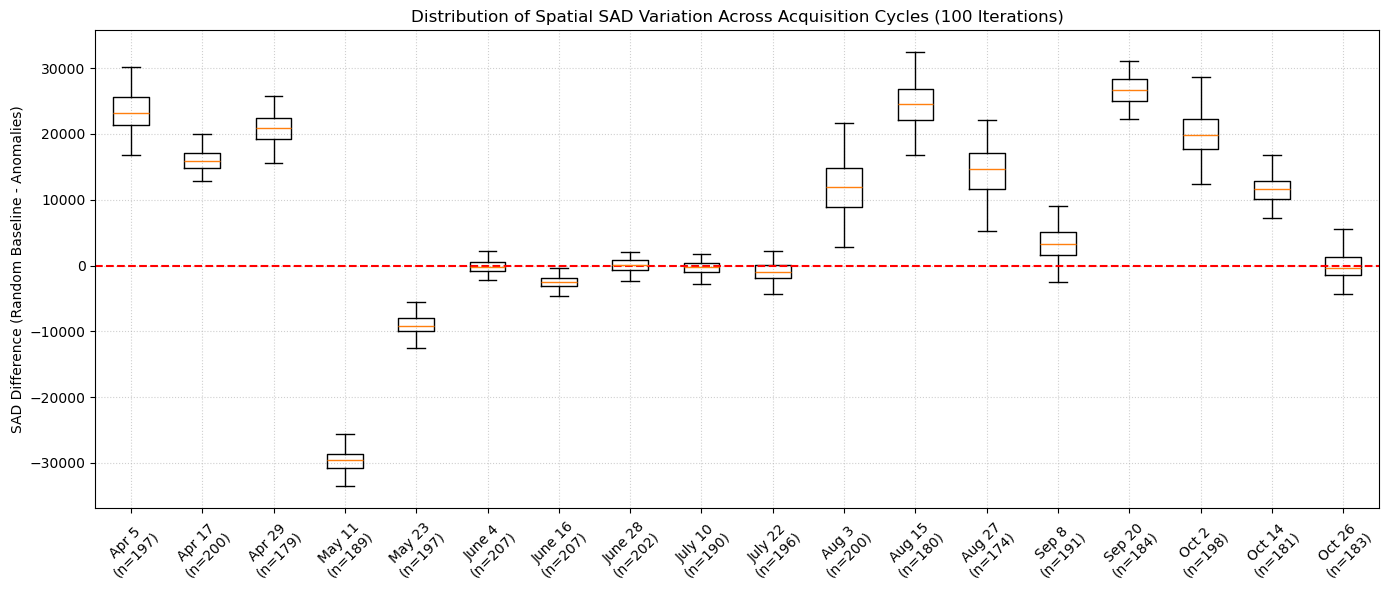

In [16]:
run_similarity_pipeline(
    25,
    "shishper_output_images",
    8,
    shishper_date_pairs,
    shishper_shape,
    "shishper_bursts/2025_04_05/VV_shape.tif",
    "shishper_bursts/2025_04_05/VH_shape.tif",
    n_iterations=100,
    metrics_to_run=['sad']
)


RUNNING PIPELINE METRIC: SSIM
Apr 5 — n=197 pts
   Mean Difference (Random - Significant): -0.001081
   Mann-Whitney U statistical value: 4500.00 | p-value: 9.04e-01
   Cohen's d: -0.0857
Apr 17 — n=200 pts
   Mean Difference (Random - Significant): 0.063716
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 5.6322
Apr 29 — n=179 pts
   Mean Difference (Random - Significant): 0.030032
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 2.4425
May 11 — n=189 pts
   Mean Difference (Random - Significant): 0.049282
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 4.1670
May 23 — n=197 pts
   Mean Difference (Random - Significant): 0.023964
   Mann-Whitney U statistical value: 9700.00 | p-value: 6.13e-35
   Cohen's d: 1.8841
June 4 — n=207 pts
   Mean Difference (Random - Significant): 0.055576
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 5.2524
June 16 — n=207 pts
  

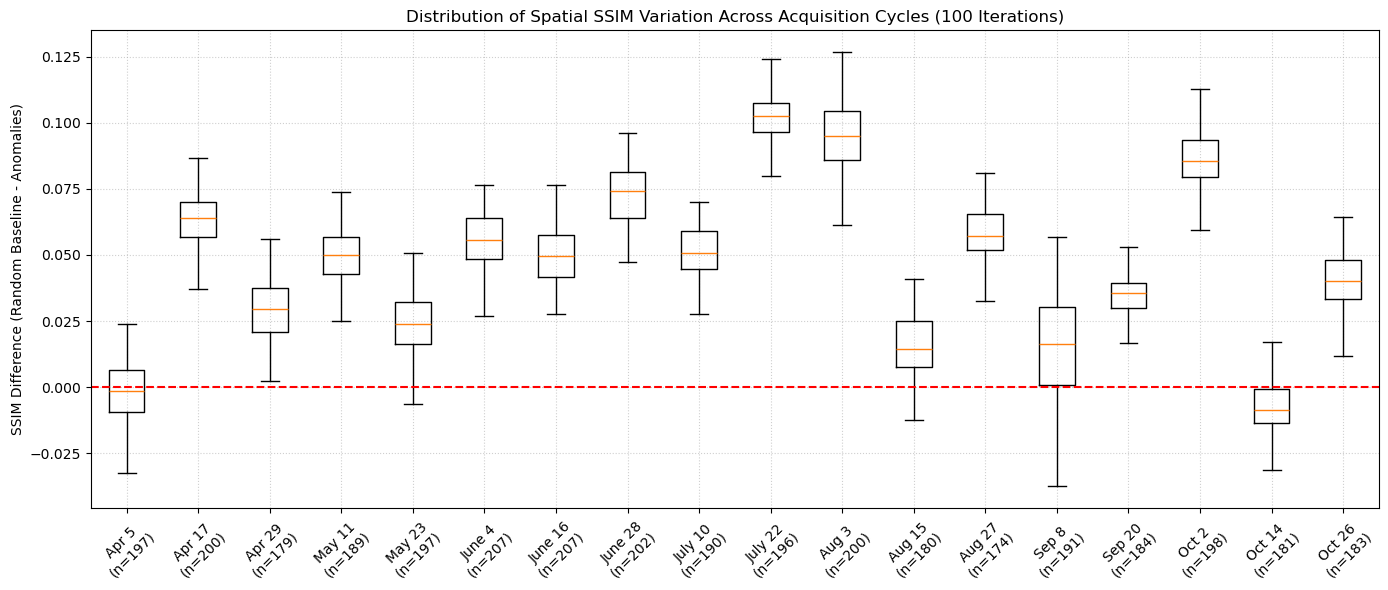

In [17]:
run_similarity_pipeline(
    25,
    "shishper_output_images",
    8,
    shishper_date_pairs,
    shishper_shape,
    "shishper_bursts/2025_04_05/VV_shape.tif",
    "shishper_bursts/2025_04_05/VH_shape.tif",
    n_iterations=100,
    metrics_to_run=['ssim']
)


RUNNING PIPELINE METRIC: MI
Apr 5 — n=197 pts
   Mean Difference (Random - Significant): 0.061224
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 2.9560
Apr 17 — n=200 pts
   Mean Difference (Random - Significant): 0.175003
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 9.1866
Apr 29 — n=179 pts
   Mean Difference (Random - Significant): 0.053130
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 2.5483
May 11 — n=189 pts
   Mean Difference (Random - Significant): 0.204046
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 11.0108
May 23 — n=197 pts
   Mean Difference (Random - Significant): 0.040957
   Mann-Whitney U statistical value: 9800.00 | p-value: 2.35e-36
   Cohen's d: 2.1600
June 4 — n=207 pts
   Mean Difference (Random - Significant): 0.250440
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 12.0013
June 16 — n=207 pts
   

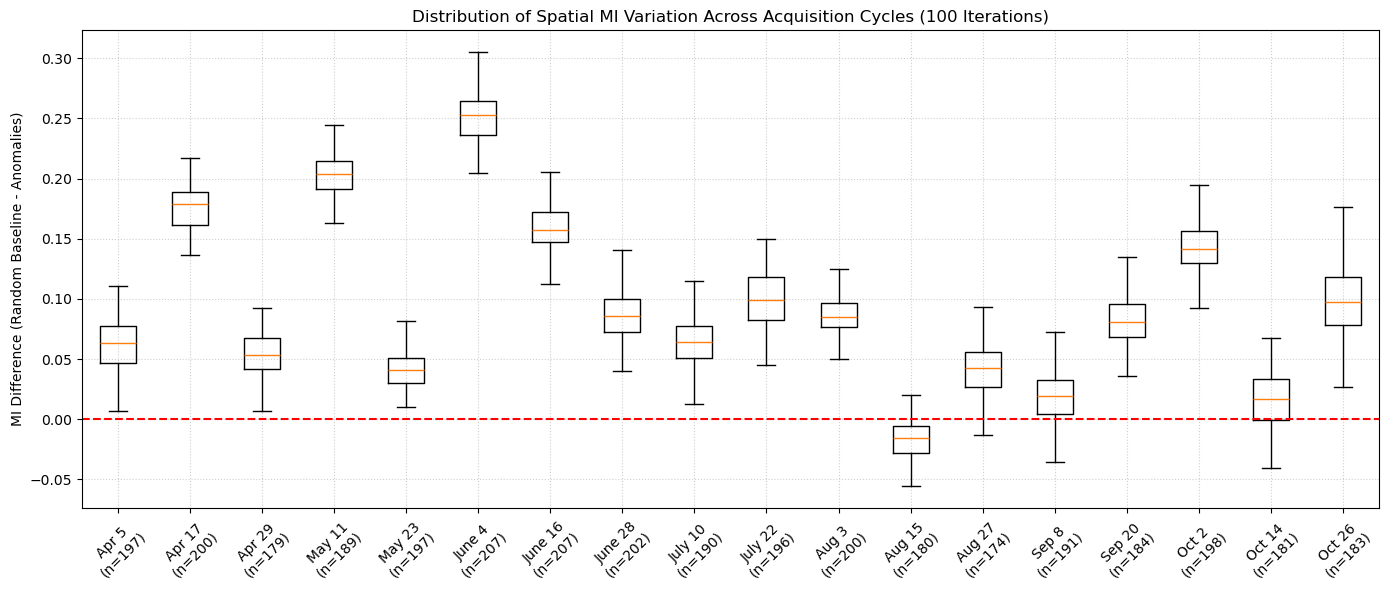

In [18]:
run_similarity_pipeline(
    25,
    "shishper_output_images",
    8,
    shishper_date_pairs,
    shishper_shape,
    "shishper_bursts/2025_04_05/VV_shape.tif",
    "shishper_bursts/2025_04_05/VH_shape.tif",
    n_iterations=100,
    metrics_to_run=['mi']
)


RUNNING PIPELINE METRIC: ZNCC
Apr 5 — n=197 pts
   Mean Difference (Random - Significant): 0.023914
   Mann-Whitney U statistical value: 9400.00 | p-value: 7.25e-31
   Cohen's d: 1.7790
Apr 17 — n=200 pts
   Mean Difference (Random - Significant): 0.068324
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 8.3369
Apr 29 — n=179 pts
   Mean Difference (Random - Significant): 0.007503
   Mann-Whitney U statistical value: 7800.00 | p-value: 1.31e-13
   Cohen's d: 0.7719
May 11 — n=189 pts
   Mean Difference (Random - Significant): 0.061716
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 5.5217
May 23 — n=197 pts
   Mean Difference (Random - Significant): 0.033940
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 3.7522
June 4 — n=207 pts
   Mean Difference (Random - Significant): 0.049908
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 6.1484
June 16 — n=207 pts
   M

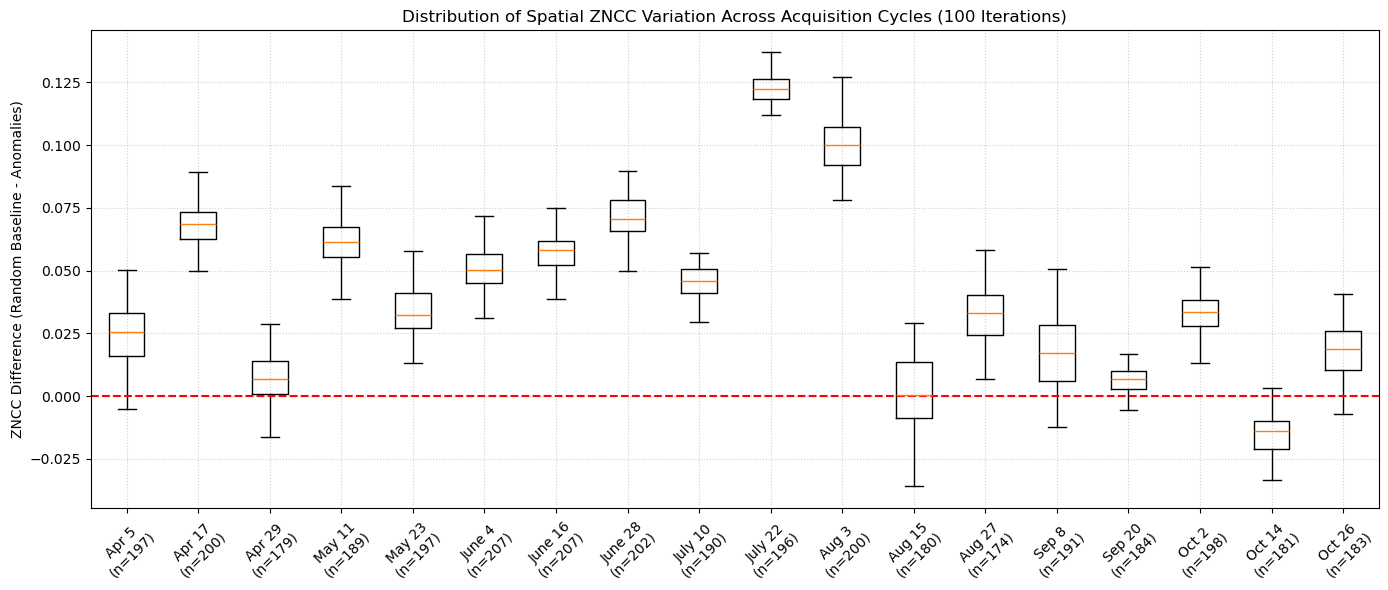

In [19]:
run_similarity_pipeline(
    25,
    "shishper_output_images",
    8,
    shishper_date_pairs,
    shishper_shape,
    "shishper_bursts/2025_04_05/VV_shape.tif",
    "shishper_bursts/2025_04_05/VH_shape.tif",
    n_iterations=100,
    metrics_to_run=['zncc']
)


RUNNING PIPELINE METRIC: FSIM
Apr 5 — n=197 pts
   Mean Difference (Random - Significant): 0.011941
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 4.9613
Apr 17 — n=200 pts
   Mean Difference (Random - Significant): 0.013655
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 6.7828
Apr 29 — n=179 pts
   Mean Difference (Random - Significant): 0.013219
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 5.7922
May 11 — n=189 pts
   Mean Difference (Random - Significant): 0.012976
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 6.2652
May 23 — n=197 pts
   Mean Difference (Random - Significant): 0.004931
   Mann-Whitney U statistical value: 9700.00 | p-value: 6.13e-35
   Cohen's d: 2.1014
June 4 — n=207 pts
   Mean Difference (Random - Significant): 0.010446
   Mann-Whitney U statistical value: 10000.00 | p-value: 2.82e-39
   Cohen's d: 4.9722
June 16 — n=207 pts
   

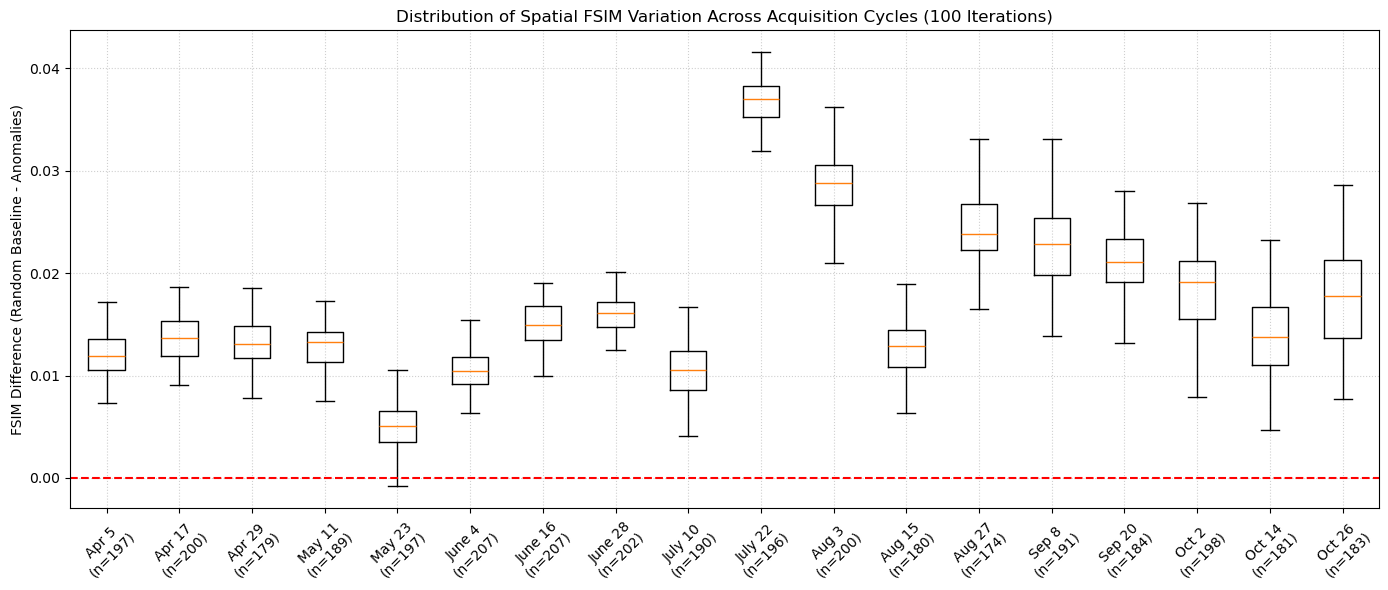

In [20]:
run_similarity_pipeline(
    25,
    "shishper_output_images",
    8,
    shishper_date_pairs,
    shishper_shape,
    "shishper_bursts/2025_04_05/VV_shape.tif",
    "shishper_bursts/2025_04_05/VH_shape.tif",
    n_iterations=100,
    metrics_to_run=['fsim']
)

<h2> Glacier d'Otemma Validation</h2>

In [21]:
# Define directory paths
otemma_base_dir = "otemma_bursts"
otemma_shape = "shapefile/shape.shp"

In [22]:
time_series_otemma=crop_tiff_to_shapefile(otemma_base_dir, otemma_shape)


Processing burst folder: 2017_08_20
   Cropped TIFF saved at: otemma_bursts\2017_08_20\VV_shape.tif
   VV processed: otemma_bursts\2017_08_20\VV_shape.tif
   Cropped TIFF saved at: otemma_bursts\2017_08_20\VH_shape.tif
   VH processed: otemma_bursts\2017_08_20\VH_shape.tif

Processing burst folder: 2017_09_01
   Cropped TIFF saved at: otemma_bursts\2017_09_01\VV_shape.tif
   VV processed: otemma_bursts\2017_09_01\VV_shape.tif
   Cropped TIFF saved at: otemma_bursts\2017_09_01\VH_shape.tif
   VH processed: otemma_bursts\2017_09_01\VH_shape.tif

Processing burst folder: 2017_09_13
   Cropped TIFF saved at: otemma_bursts\2017_09_13\VV_shape.tif
   VV processed: otemma_bursts\2017_09_13\VV_shape.tif
   Cropped TIFF saved at: otemma_bursts\2017_09_13\VH_shape.tif
   VH processed: otemma_bursts\2017_09_13\VH_shape.tif

Processing burst folder: 2017_09_25
   Cropped TIFF saved at: otemma_bursts\2017_09_25\VV_shape.tif
   VV processed: otemma_bursts\2017_09_25\VV_shape.tif
   Cropped TIFF sav

In [23]:
save_cropped_polarizations_plot(time_series_otemma,otemma_shape, "otemma_output_images")

 Plot saved at: otemma_output_images\VV_VH_cropped\2017_08_20.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_09_01.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_09_13.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_09_25.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_10_07.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_10_19.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_10_31.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_11_12.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_11_24.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_12_06.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_12_18.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2017_12_30.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2018_01_11.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2018_01_23.png
 Plot saved at: otemma_output_images\VV_VH_cropped\2018_02_04.png
 Plot save

In [24]:
vv_stack, vh_stack = compile_temporal_stacks(time_series_otemma)

In [25]:
ratios = compute_and_plot_pixel_stats(time_series_otemma, vv_stack, vh_stack, "otemma_pixel_stats", "otemma_output_images", otemma_shape )
compute_cv_and_plot("otemma_pixel_stats", "otemma_output_images", otemma_shape)
compute_excluding_max_vv(time_series, vv_stack, vh_stack, ratios, "otemma_pixel_stats", "otemma_output_images", otemma_shape)

C:\Users\Izba\Desktop\thesis_reusable\change_detection.py:1089: RuntimeWarning: Mean of empty slice
  stats_dict["VV_VH_mean"] = np.nanmean(
C:\Users\Izba\.conda\envs\sds\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\Izba\Desktop\thesis_reusable\change_detection.py:1099: RuntimeWarning: All-NaN slice encountered
  stats_dict["VV_VH_max"] = np.nanmax(


 Plot saved: otemma_output_images\VV_mean.png
 Plot saved: otemma_output_images\VH_mean.png
 Plot saved: otemma_output_images\VV_VH_mean.png
 Plot saved: otemma_output_images\VV_std.png
 Plot saved: otemma_output_images\VH_std.png
 Plot saved: otemma_output_images\VV_VH_std.png
 Plot saved: otemma_output_images\VV_max.png
 Plot saved: otemma_output_images\VH_max.png
 Plot saved: otemma_output_images\VV_VH_max.png
 Plot saved: otemma_output_images\VV_CV.png
 Plot saved: otemma_output_images\VH_CV.png
 Plot saved: otemma_output_images\VV_VH_CV.png


C:\Users\Izba\Desktop\thesis_reusable\change_detection.py:1654: RuntimeWarning: Mean of empty slice
  np.nanmean(
C:\Users\Izba\.conda\envs\sds\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


 Plot saved: otemma_output_images\VV_excluding_max_mean.png
 Plot saved: otemma_output_images\VV_VH_excluding_max_mean.png
 Plot saved: otemma_output_images\VV_excluding_max_std.png
 Plot saved: otemma_output_images\VV_VH_excluding_max_std.png


In [26]:
detect_anomalies_isolation_forest(vv_stack, vh_stack, time_series_otemma, "otemma_isolation_forest", 3, 0.001)

  Date: 2017-08-20 → Isolated 2 active anomalous points.
  Date: 2017-09-01 → Isolated 2 active anomalous points.
  Date: 2017-09-13 → Isolated 2 active anomalous points.
  Date: 2017-09-25 → Isolated 2 active anomalous points.
  Date: 2017-10-07 → Isolated 2 active anomalous points.
  Date: 2017-10-19 → Isolated 2 active anomalous points.
  Date: 2017-10-31 → Isolated 2 active anomalous points.
  Date: 2017-11-12 → Isolated 2 active anomalous points.
  Date: 2017-11-24 → Isolated 2 active anomalous points.
  Date: 2017-12-06 → Isolated 2 active anomalous points.
  Date: 2017-12-18 → Isolated 2 active anomalous points.
  Date: 2017-12-30 → Isolated 2 active anomalous points.
  Date: 2018-01-11 → Isolated 2 active anomalous points.
  Date: 2018-01-23 → Isolated 0 active anomalous points.
  Date: 2018-02-04 → Isolated 0 active anomalous points.
  Date: 2018-02-16 → Isolated 2 active anomalous points.
  Date: 2018-02-28 → Isolated 1 active anomalous points.
  Date: 2018-03-12 → Isolated 2

In [27]:
otemma_date_pairs= [
    ("08/20/2017", "otemma_aligned_nn/2017_08_02.tif", "otemma_aligned_nn/2017_08_23.tif", "otemma_isolation_forest/VV_VH_anomaly_2017-08-20.tif"),
    ("09/01/2017", "otemma_aligned_nn/2017_08_23.tif", "otemma_aligned_nn/2017_09_08.tif", "otemma_isolation_forest/VV_VH_anomaly_2017-09-01.tif"),
    ("09/13/2017", "otemma_aligned_nn/2017_09_08.tif", "otemma_aligned_nn/2017_09_16.tif", "otemma_isolation_forest/VV_VH_anomaly_2017-09-13.tif"),
    ("09/25/2017", "otemma_aligned_nn/2017_09_16.tif", "otemma_aligned_nn/2017_09_28.tif", "otemma_isolation_forest/VV_VH_anomaly_2017-09-25.tif"),
    ("10/07/2017", "otemma_aligned_nn/2017_09_28.tif", "otemma_aligned_nn/2017_10_10.tif", "otemma_isolation_forest/VV_VH_anomaly_2017-10-07.tif"),
    ("06/28/2018", "otemma_aligned_nn/2018_06_25.tif", "otemma_aligned_nn/2018_07_01.tif", "otemma_isolation_forest/VV_VH_anomaly_2018-06-28.tif"),
    ("07/10/2018", "otemma_aligned_nn/2018_07_04.tif", "otemma_aligned_nn/2018_07_18.tif", "otemma_isolation_forest/VV_VH_anomaly_2018-07-10.tif"),
    ("07/22/2018", "otemma_aligned_nn/2018_07_18.tif", "otemma_aligned_nn/2018_07_25.tif", "otemma_isolation_forest/VV_VH_anomaly_2018-07-22.tif"),
    ("08/03/2018", "otemma_aligned_nn/2018_07_29.tif", "otemma_aligned_nn/2018_08_11.tif", "otemma_isolation_forest/VV_VH_anomaly_2018-08-03.tif"),
    ("08/15/2018", "otemma_aligned_nn/2018_08_03.tif", "otemma_aligned_nn/2018_08_16.tif", "otemma_isolation_forest/VV_VH_anomaly_2018-08-15.tif")
    
]



RUNNING PIPELINE METRIC: FSIM
08/20/2017 — n=2 pts
   Mean Difference (Random - Significant): 0.015620
   Mann-Whitney U statistical value: 8300.00 | p-value: 3.39e-18
   Cohen's d: 0.8797
09/01/2017 — n=2 pts
   Mean Difference (Random - Significant): -0.008163
   Mann-Whitney U statistical value: 3900.00 | p-value: 9.98e-01
   Cohen's d: -0.3577
09/13/2017 — n=1 pts
   Mean Difference (Random - Significant): -0.054025
   Mann-Whitney U statistical value: 2700.00 | p-value: 1.00e+00
   Cohen's d: -0.7168
09/25/2017 — n=2 pts
   Mean Difference (Random - Significant): 0.080509
   Mann-Whitney U statistical value: 9000.00 | p-value: 7.56e-26
   Cohen's d: 1.3358
10/07/2017 — n=2 pts
   Mean Difference (Random - Significant): 0.062911
   Mann-Whitney U statistical value: 7800.00 | p-value: 1.31e-13
   Cohen's d: 0.8986
06/28/2018 — n=2 pts
   Mean Difference (Random - Significant): 0.039128
   Mann-Whitney U statistical value: 7500.00 | p-value: 3.31e-11
   Cohen's d: 0.7467
07/10/2018 

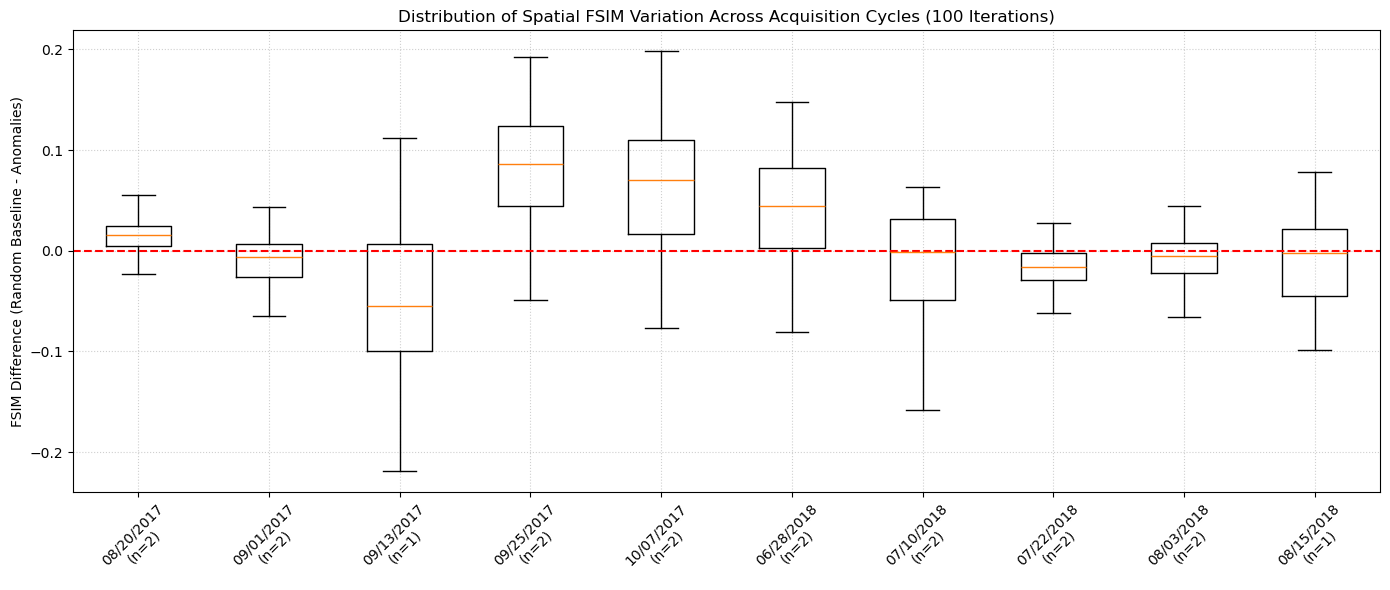

In [28]:
run_similarity_pipeline(
    25,
    "otemma_output_images",
    4,
    otemma_date_pairs,
    otemma_shape,
    "otemma_bursts/2017_08_20/VV_shape.tif",
    "otemma_bursts/2017_08_20/VH_shape.tif",
    n_iterations=100,
    metrics_to_run=['fsim']
)

<h2> DSM Validation </h2>

In [29]:
from change_detection import (
    plot_dsm_difference,
    plot_anomaly_points_on_dsm
)

Saving DSM TIFF to: C:\Users\Izba\Desktop\thesis_reusable\otemma_output_images\dsm_difference.tif
Saving DSM plot to: C:\Users\Izba\Desktop\thesis_reusable\otemma_output_images\dsm_difference.png


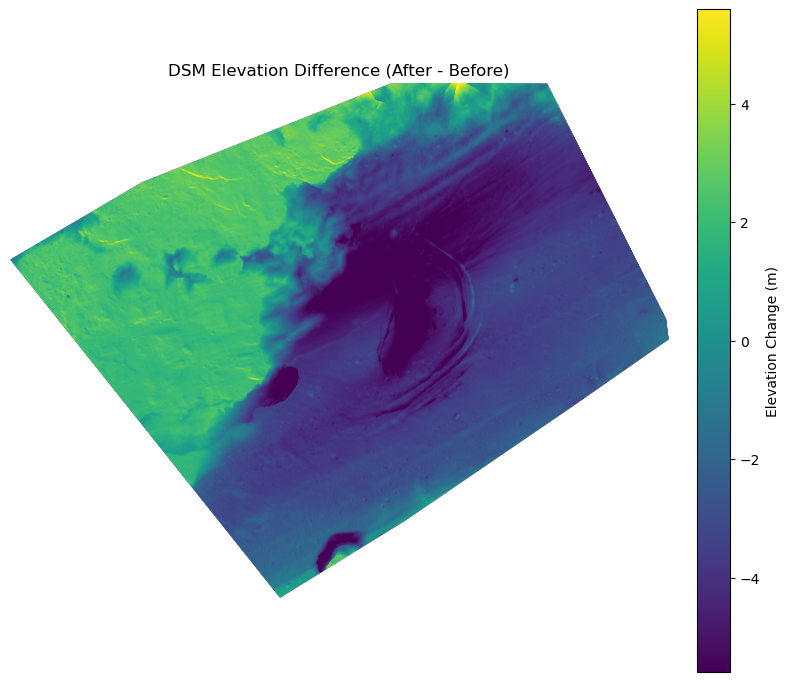

In [30]:
dsm_tif = plot_dsm_difference(
    before_dsm="Otemma2017_2018/2017/Otemma_16Aug2017_dsm.tif",
    after_dsm="Otemma2017_2018/2018/21082018_DEM.tif",
    shapefile= otemma_shape,
    output_dir="otemma_output_images"
)



In [31]:
anomaly_list_otemma = [
    ("08/20/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-08-20.tif"),
    ("09/01/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-09-01.tif"),
    ("09/13/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-09-13.tif"),
    ("09/25/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-09-25.tif"),
    ("10/07/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-10-07.tif"),
    ("10/19/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-10-19.tif"),
    ("10/31/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-10-31.tif"),
    ("11/12/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-11-12.tif"),
    ("11/24/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-11-24.tif"),
    ("12/06/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-12-06.tif"),
    ("12/18/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-12-18.tif"),
    ("12/30/2017", "otemma_isolation_forest/VV_VH_anomaly_2017-12-30.tif"),
    ("01/11/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-01-11.tif"),
    ("01/23/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-01-23.tif"),
    ("02/04/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-02-04.tif"),
    ("02/16/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-02-16.tif"),
    ("02/28/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-02-28.tif"),
    
    ("03/12/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-03-12.tif"),
    ("03/24/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-03-24.tif"),
    
    ("04/05/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-04-05.tif"),
    ("04/17/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-04-17.tif"),
    ("04/29/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-04-29.tif"),
    
    ("05/11/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-05-11.tif"),
    ("05/23/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-05-23.tif"),
    
    ("06/04/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-06-04.tif"),
    ("06/16/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-06-16.tif"),
    
    ("06/28/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-06-28.tif"),
    ("07/10/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-07-10.tif"),
    ("07/22/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-07-22.tif"),
    ("08/03/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-08-03.tif"),
    ("08/15/2018", "otemma_isolation_forest/VV_VH_anomaly_2018-08-15.tif")
]


Saving DSM plot to: C:\Users\Izba\Desktop\thesis_reusable\otemma_output_images\anomaly_points.png


C:\Users\Izba\Desktop\thesis_reusable\change_detection.py:5702: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


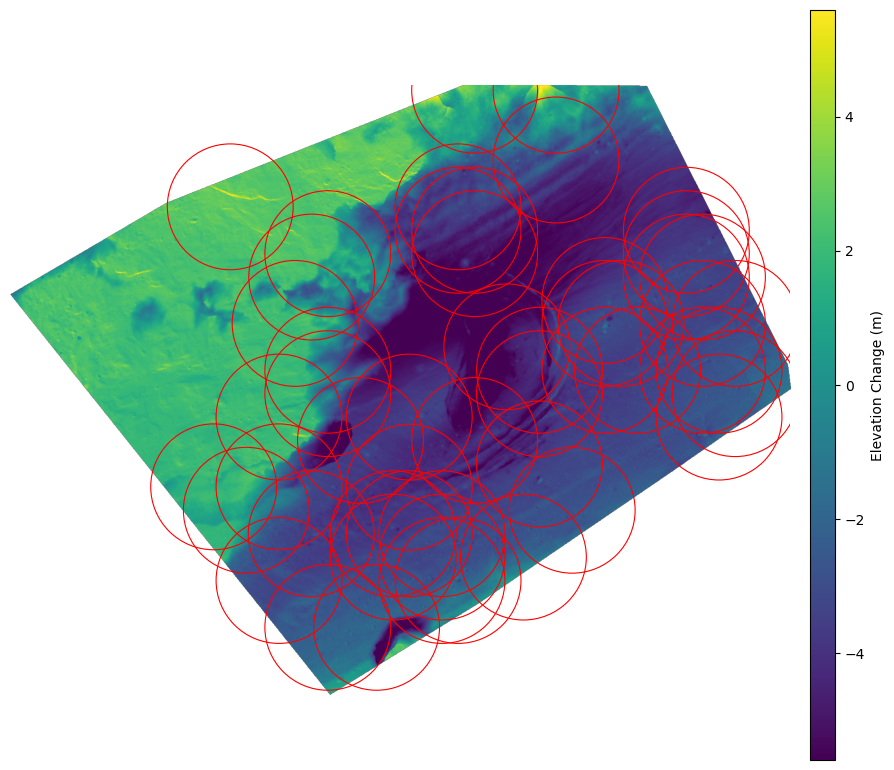

'C:\\Users\\Izba\\Desktop\\thesis_reusable\\otemma_output_images\\anomaly_points.png'

In [32]:
plot_anomaly_points_on_dsm(
    dsm_tif=dsm_tif,
    anomaly_tifs=anomaly_list_otemma,
    output_dir="otemma_output_images",
    shapefile_path=otemma_shape,
    patch_diameter_m=75
)